# 20 - ML on Independent Dataset (1 Study Per Patient)

Repeat the NB 17b joint optimization approach on the independent dataset (55 studies from 55 patients). This eliminates repeated-measures bias from the ML evaluation.

**Key difference from NB 17b:** Use 10-fold stratified CV as the primary evaluation (Gemma's suggestion for this sample size). Also run LOOCV as a comparison point.

**Methodology:**
- Correlation removal: |r| > 0.9, guided by NB 19 p-values
- Pipeline: StandardScaler -> SelectKBest(f_classif) -> model
- Grid search: 10-fold stratified CV (primary), LOOCV (comparison)
- 4 models: LogReg, RF, SVM, NaiveBayes
- Joint optimization over feature count (k) and hyperparameters
- Random state: 42 everywhere

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")

print("Imports OK")

Imports OK


In [2]:
df = pd.read_csv(os.path.join("reports", "18_independent_dataset.csv"))
feature_cols = [c for c in df.columns if c.startswith("original_")]
y = df["rejection"].values

# Remove correlated features (|r| > 0.9), guided by NB 19 p-values
stats_df = pd.read_csv(os.path.join("reports", "19_stats_independent_dataset.csv"))
p_values = dict(zip(stats_df["feature"], stats_df["p_value"]))

corr = df[feature_cols].corr().abs()
to_drop = set()
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if corr.iloc[i, j] > 0.9:
            fi, fj = feature_cols[i], feature_cols[j]
            if fi in to_drop or fj in to_drop:
                continue
            if p_values.get(fi, 1.0) <= p_values.get(fj, 1.0):
                to_drop.add(fj)
            else:
                to_drop.add(fi)

reduced_features = [f for f in feature_cols if f not in to_drop]
X = df[reduced_features].values

print(f"Independent dataset: {len(df)} studies, {df['patient_id'].nunique()} patients")
print(f"Class balance: {(y == 0).sum()} no-rej, {(y == 1).sum()} rej")
print(f"Features: {len(feature_cols)} -> {len(reduced_features)} after correlation removal")

Independent dataset: 55 studies, 55 patients
Class balance: 34 no-rej, 21 rej
Features: 93 -> 31 after correlation removal


In [3]:
def run_loocv_pipe(X, y, make_pipe):
    loo = LeaveOneOut()
    y_proba = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        pipe = make_pipe()
        pipe.fit(X[train_idx], y[train_idx])
        y_proba[test_idx] = pipe.predict_proba(X[test_idx])[:, 1]
    return y_proba


def compute_youden(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    J = tpr - fpr
    best = np.argmax(J)
    return {
        "auc": auc, "threshold": thresholds[best],
        "sensitivity": tpr[best], "specificity": 1 - fpr[best],
        "fpr": fpr, "tpr": tpr,
    }

## Define pipelines and grids

In [4]:
k_values = [5, 10, 15, 20, 31]

def make_pipe(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif)),
        ("model", model),
    ])

pipelines = {
    "LogReg": {
        "pipe": make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        "grid": {"select__k": k_values, "model__C": [0.01, 0.1, 1.0, 10.0]},
    },
    "RF": {
        "pipe": make_pipe(RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
        "grid": {"select__k": k_values, "model__max_depth": [3, 5, 7], "model__min_samples_leaf": [3, 5, 10]},
    },
    "SVM": {
        "pipe": make_pipe(SVC(probability=True, class_weight="balanced", random_state=42)),
        "grid": {"select__k": k_values, "model__C": [0.1, 1.0, 10.0], "model__kernel": ["linear", "rbf"]},
    },
    "NaiveBayes": {
        "pipe": make_pipe(GaussianNB()),
        "grid": {"select__k": k_values, "model__var_smoothing": [1e-9, 1e-7, 1e-5]},
    },
}

print("Pipelines defined:")
for name, spec in pipelines.items():
    n_combos = 1
    for vals in spec["grid"].values():
        n_combos *= len(vals)
    print(f"  {name}: {n_combos} combinations")

Pipelines defined:
  LogReg: 20 combinations
  RF: 45 combinations
  SVM: 30 combinations
  NaiveBayes: 15 combinations


## 10-fold stratified CV (primary evaluation)

For each model, GridSearchCV finds the best (k, hyperparams) combo using an inner 5-fold CV. Then we evaluate that best pipeline with 10-fold stratified CV to get the final AUC estimate.

In [5]:
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_outer = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results_10fold = []
cv10_probas = {}

for name, spec in pipelines.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")

    # Grid search on full data to find best params
    gs = GridSearchCV(spec["pipe"], spec["grid"], cv=cv_inner, scoring="roc_auc", n_jobs=-1)
    gs.fit(X, y)
    print(f"  Best inner CV AUC: {gs.best_score_:.3f}")
    print(f"  Best params: {gs.best_params_}")

    # Evaluate best pipeline with 10-fold CV
    best_pipe = gs.best_estimator_
    y_proba = cross_val_predict(
        clone(best_pipe), X, y, cv=cv_outer, method="predict_proba"
    )[:, 1]
    res = compute_youden(y, y_proba)
    cv10_probas[name] = {"y_proba": y_proba, **res}

    print(f"  10-fold CV AUC: {res['auc']:.3f}")
    print(f"  Sensitivity: {res['sensitivity']:.3f}  Specificity: {res['specificity']:.3f}")

    results_10fold.append({
        "model": name,
        "best_k": gs.best_params_["select__k"],
        "best_params": str({k: v for k, v in gs.best_params_.items() if k != "select__k"}),
        "cv10_auc": round(res["auc"], 3),
        "sensitivity": round(res["sensitivity"], 3),
        "specificity": round(res["specificity"], 3),
    })

results_10fold_df = pd.DataFrame(results_10fold)
print(f"\n\n{'='*60}")
print("SUMMARY - 10-fold stratified CV:")
print(f"{'='*60}")
print(results_10fold_df.to_string(index=False))


LogReg


/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: Run

  Best inner CV AUC: 0.619
  Best params: {'model__C': 0.01, 'select__k': 15}
  10-fold CV AUC: 0.569
  Sensitivity: 0.714  Specificity: 0.471

RF


  Best inner CV AUC: 0.607
  Best params: {'model__max_depth': 3, 'model__min_samples_leaf': 10, 'select__k': 10}


  10-fold CV AUC: 0.506
  Sensitivity: 0.238  Specificity: 0.941

SVM
  Best inner CV AUC: 0.570
  Best params: {'model__C': 0.1, 'model__kernel': 'linear', 'select__k': 5}
  10-fold CV AUC: 0.283
  Sensitivity: 1.000  Specificity: 0.029

NaiveBayes
  Best inner CV AUC: 0.584
  Best params: {'model__var_smoothing': 1e-09, 'select__k': 10}
  10-fold CV AUC: 0.508
  Sensitivity: 0.143  Specificity: 1.000


SUMMARY - 10-fold stratified CV:
     model  best_k                                            best_params  cv10_auc  sensitivity  specificity
    LogReg      15                                     {'model__C': 0.01}     0.569        0.714        0.471
        RF      10 {'model__max_depth': 3, 'model__min_samples_leaf': 10}     0.506        0.238        0.941
       SVM       5           {'model__C': 0.1, 'model__kernel': 'linear'}     0.283        1.000        0.029
NaiveBayes      10                        {'model__var_smoothing': 1e-09}     0.508        0.143        1.000


## LOOCV (comparison)

Run LOOCV with the same best pipelines for comparison with NB 17b results.

In [6]:
results_loocv = []
loocv_probas = {}

for name, spec in pipelines.items():
    # Refit grid search to get best params
    gs = GridSearchCV(spec["pipe"], spec["grid"], cv=cv_inner, scoring="roc_auc", n_jobs=-1)
    gs.fit(X, y)

    best_pipe = gs.best_estimator_
    y_proba = run_loocv_pipe(X, y, lambda p=best_pipe: clone(p))
    res = compute_youden(y, y_proba)
    loocv_probas[name] = {"y_proba": y_proba, **res}

    print(f"{name:12s}  LOOCV AUC={res['auc']:.3f}  "
          f"sens={res['sensitivity']:.3f}  spec={res['specificity']:.3f}")

    results_loocv.append({
        "model": name,
        "loocv_auc": round(res["auc"], 3),
        "sensitivity": round(res["sensitivity"], 3),
        "specificity": round(res["specificity"], 3),
    })

/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/linear_mo

LogReg        LOOCV AUC=0.595  sens=0.333  spec=0.912


RF            LOOCV AUC=0.522  sens=0.286  spec=0.971
SVM           LOOCV AUC=0.433  sens=0.333  spec=0.794


NaiveBayes    LOOCV AUC=0.492  sens=0.143  spec=1.000


## ROC curves

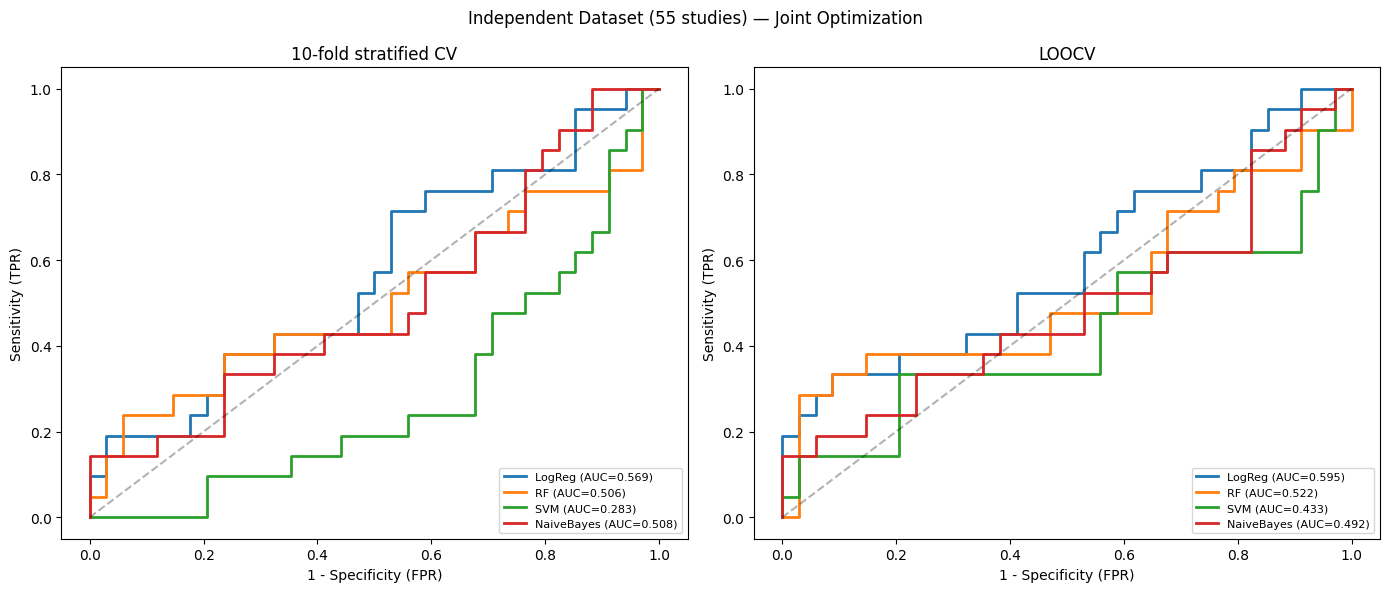

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for idx, (name, res) in enumerate(cv10_probas.items()):
    axes[0].plot(res["fpr"], res["tpr"], linewidth=2, color=colors[idx],
                 label=f"{name} (AUC={res['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("1 - Specificity (FPR)")
axes[0].set_ylabel("Sensitivity (TPR)")
axes[0].set_title("10-fold stratified CV")
axes[0].legend(loc="lower right", fontsize=8)

for idx, (name, res) in enumerate(loocv_probas.items()):
    axes[1].plot(res["fpr"], res["tpr"], linewidth=2, color=colors[idx],
                 label=f"{name} (AUC={res['auc']:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_xlabel("1 - Specificity (FPR)")
axes[1].set_ylabel("Sensitivity (TPR)")
axes[1].set_title("LOOCV")
axes[1].legend(loc="lower right", fontsize=8)

fig.suptitle("Independent Dataset (55 studies) - Joint Optimization", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join("reports", "20_roc_independent_dataset.png"), dpi=150, bbox_inches="tight")
plt.show()

## Compare with full dataset results (NB 17b)

In [8]:
full_results = pd.read_csv(os.path.join("reports", "17b_joint_optimization_results.csv"))

print(f"{'Model':12s}  {'Full (137, LOOCV)':>18s}  {'Indep (55, 10-fold)':>20s}  {'Indep (55, LOOCV)':>18s}")
print("-" * 75)
for i, row_10f in enumerate(results_10fold):
    name = row_10f["model"]
    full_row = full_results[full_results["model"] == name]
    full_auc = full_row["loocv_auc"].values[0] if len(full_row) > 0 else float("nan")
    loocv_auc = results_loocv[i]["loocv_auc"]
    print(f"{name:12s}  {full_auc:>18.3f}  {row_10f['cv10_auc']:>20.3f}  {loocv_auc:>18.3f}")

Model          Full (137, LOOCV)   Indep (55, 10-fold)   Indep (55, LOOCV)
---------------------------------------------------------------------------
LogReg                     0.501                 0.569               0.595
RF                         0.399                 0.506               0.522
SVM                        0.531                 0.283               0.433
NaiveBayes                 0.537                 0.508               0.492


## Bootstrap 95% confidence intervals on 10-fold CV AUC

1000 bootstrap resamples of the 10-fold CV predictions to estimate uncertainty.

In [9]:
rng = np.random.RandomState(42)
n_bootstrap = 1000
bootstrap_rows = []

for name, res in cv10_probas.items():
    y_proba = res["y_proba"]
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y[idx], y_proba[idx]))
    ci_lo = np.percentile(aucs, 2.5)
    ci_hi = np.percentile(aucs, 97.5)
    bootstrap_rows.append({
        "model": name,
        "cv10_auc": res["auc"],
        "ci_lower": round(ci_lo, 3),
        "ci_upper": round(ci_hi, 3),
        "n_valid_resamples": len(aucs),
    })
    print(f"{name:12s}  AUC={res['auc']:.3f}  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.to_csv(os.path.join("reports", "20_bootstrap_ci.csv"), index=False)
print(f"\nSaved to reports/20_bootstrap_ci.csv")

LogReg        AUC=0.569  95% CI [0.398, 0.716]


RF            AUC=0.506  95% CI [0.331, 0.679]


SVM           AUC=0.283  95% CI [0.148, 0.433]


NaiveBayes    AUC=0.508  95% CI [0.356, 0.659]

Saved to reports/20_bootstrap_ci.csv


## Full vs independent dataset AUC comparison

Grouped bar chart comparing AUC across the full dataset (LOOCV) and independent dataset (10-fold CV with CI, LOOCV).

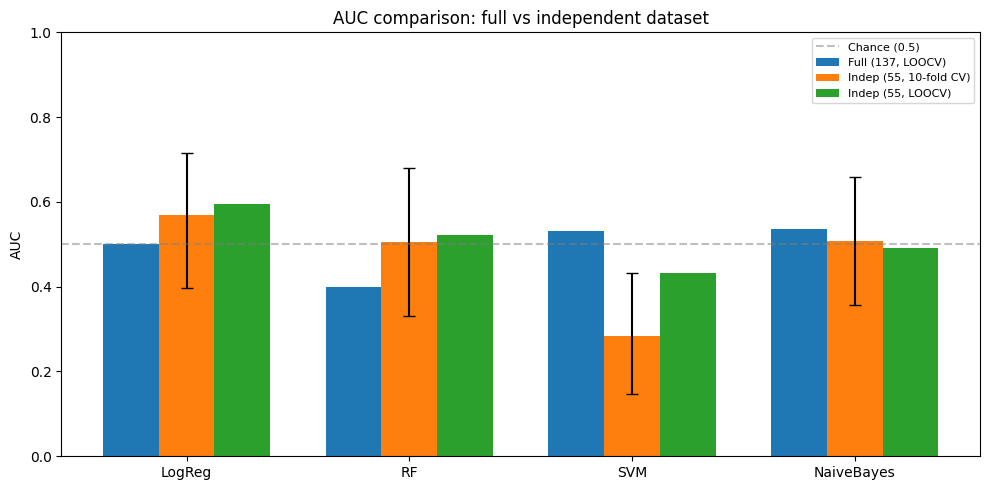

Saved to reports/20_comparison_full_vs_independent.png


In [10]:
models = [r["model"] for r in results_10fold]
full_aucs = []
for name in models:
    row = full_results[full_results["model"] == name]
    full_aucs.append(row["loocv_auc"].values[0] if len(row) > 0 else 0)
indep_10f_aucs = [r["cv10_auc"] for r in results_10fold]
indep_loocv_aucs = [r["loocv_auc"] for r in results_loocv]

ci_lower = bootstrap_df["ci_lower"].values
ci_upper = bootstrap_df["ci_upper"].values
errors = [np.array(indep_10f_aucs) - ci_lower, ci_upper - np.array(indep_10f_aucs)]

x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, full_aucs, w, label="Full (137, LOOCV)", color="#1f77b4")
ax.bar(x, indep_10f_aucs, w, yerr=errors, capsize=4, label="Indep (55, 10-fold CV)", color="#ff7f0e")
ax.bar(x + w, indep_loocv_aucs, w, label="Indep (55, LOOCV)", color="#2ca02c")

ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance (0.5)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("AUC")
ax.set_ylim(0, 1)
ax.set_title("AUC comparison: full vs independent dataset")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join("reports", "20_comparison_full_vs_independent.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/20_comparison_full_vs_independent.png")

## Save results

In [11]:
# Combine 10-fold and LOOCV results
combined = pd.merge(
    results_10fold_df,
    pd.DataFrame(results_loocv)[["model", "loocv_auc"]],
    on="model"
)
combined = combined.rename(columns={"loocv_auc": "loocv_auc_comparison"})

output_path = os.path.join("reports", "20_ml_independent_dataset_results.csv")
combined.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print()
print(combined.to_string(index=False))

Saved to reports/20_ml_independent_dataset_results.csv

     model  best_k                                            best_params  cv10_auc  sensitivity  specificity  loocv_auc_comparison
    LogReg      15                                     {'model__C': 0.01}     0.569        0.714        0.471                 0.595
        RF      10 {'model__max_depth': 3, 'model__min_samples_leaf': 10}     0.506        0.238        0.941                 0.522
       SVM       5           {'model__C': 0.1, 'model__kernel': 'linear'}     0.283        1.000        0.029                 0.433
NaiveBayes      10                        {'model__var_smoothing': 1e-09}     0.508        0.143        1.000                 0.492


## Interpretation

**No model achieves useful performance on the independent dataset.** The best 10-fold CV AUC is 0.569 (LogReg with k=15, C=0.01). This is marginally above chance but not clinically useful. RF and NaiveBayes sit at ~0.5 (chance), and SVM collapsed to 0.283 (worse than random).

**LOOCV and 10-fold CV disagree on rankings.** LogReg is best by both methods (0.595 LOOCV, 0.569 10-fold). But SVM scores 0.283 on 10-fold vs 0.433 on LOOCV. This instability with only 55 samples is expected and underscores that no model has learned anything reliable.

**Operating points are degenerate.** SVM predicts "rejection" for nearly everyone (sens=1.000, spec=0.029). NaiveBayes does the opposite (sens=0.143, spec=1.000). Neither is usable. LogReg has the only balanced operating point (sens=0.71, spec=0.47), but at AUC 0.57 this is not clinically meaningful.

**Comparison with full dataset (NB 17b).** LogReg improved slightly from the full dataset (0.501 -> 0.595 LOOCV), likely due to better class balance (38% vs 28% rejection). But this is still near chance. The overall pattern is the same: no model exceeds AUC ~0.6, and most are at or below 0.5.

**Conclusion.** The independent dataset confirms the full-dataset finding: B-mode ultrasound radiomics features do not carry predictive signal for pancreas transplant rejection. Removing repeated-measures bias and improving class balance does not rescue performance.